# Gaussian Process Models for Emulation

## Environment

In [315]:
%matplotlib widget

In [316]:
# For fixing type hinting - FIXED in python 3.14 but too restrictive dependency!
from __future__ import annotations  # noqa: F404

# We are going to use JAX for our computation, it will make many things much easier
import jax
from jax import config, vmap
from jax import numpy as jnp
from jax import random as jr
from jax.scipy.linalg import solve_triangular

import equinox as eqx
import optax

from matplotlib import pyplot as plt

import pandas as pd
import numpy as np

import os
from typing import NamedTuple, Tuple, Callable, Union, Optional
from functools import partial


# We will want double precision floats for matrix inversions
config.update("jax_enable_x64", True)

# We will need a "nugget" to support positive definiteness
NUGGET = 1e-9

# Start the random number chain
key = jr.key(0)

## Normal Distributions

The base of most of our computation with GPs will be to manipulate Normal distributions. Let's start by building up a few tools to abstract away much of the repeated effort.

1. Classes for Multivariate Gaussians with either dense, diagonal or isotropic covariances
2. The ability to sample from these
3. How to assess the log likelihood of these distributions

In [317]:
class MultivariateGaussian(eqx.Module):
    """Multivariate Gaussian distribution with a full covariance matrix."""

    mu: jnp.ndarray  # Shape: (N,)
    sigma: jnp.ndarray  # Shape: (N, N)

    @property
    def N(self) -> int:
        """Returns the dimensionality of the distribution."""
        return self.mu.shape[0]

    @property
    def cholesky(self) -> jnp.ndarray:
        """Computes the lower Cholesky decomposition of the covariance matrix."""
        return jnp.linalg.cholesky(self.sigma + NUGGET * jnp.identity(self.N))

    def sample(self, key: jr.PRNGKey, nsamp: int = 1) -> Tuple[jr.PRNGKey, jnp.ndarray]:
        """Generates random samples from the distribution.

        Args:
            key: JAX PRNG key.
            nsamp: Number of samples to generate.

        Returns:
            A tuple of (next_key, samples) where samples has shape (nsamp, N).
        """
        key, subkey = jr.split(key)
        L = self.cholesky

        z = jr.normal(subkey, (self.N, nsamp))
        ys = self.mu[None, :] + (L @ z).T
        return key, ys

    def loglik(self, y: jnp.ndarray) -> jnp.ndarray:
        """Computes the log-likelihood of data point(s) y.

        Args:
            y: Array of shape (N,) or (M, N) containing data points.

        Returns:
            Log-likelihood values.
        """
        L = self.cholesky
        r = jnp.atleast_2d(y) - jnp.atleast_2d(self.mu)
        R = (solve_triangular(L, r.T, lower=True) ** 2).sum(0)

        return -self.N * jnp.log(2 * jnp.pi) / 2 - jnp.log(L.diagonal()).sum() - 0.5 * R


class DiagonalGaussian(eqx.Module):
    """Multivariate Gaussian distribution with a diagonal covariance matrix.

    `sigma` is a 1D array representing variances for each dimension.
    """

    mu: jnp.ndarray  # Shape: (N,)
    sigma: jnp.ndarray  # Shape: (N,) - Variances

    @property
    def N(self) -> int:
        """Returns the dimensionality of the distribution."""
        return self.mu.shape[0]

    def sample(self, key: jr.PRNGKey, nsamp: int = 1) -> Tuple[jr.PRNGKey, jnp.ndarray]:
        """Generates random samples from the distribution."""
        key, subkey = jr.split(key)
        ys = self.mu[None, :] + jr.normal(subkey, (nsamp, self.N)) * jnp.sqrt(
            self.sigma[None, :]
        )
        return key, ys

    def loglik(self, y: jnp.ndarray) -> jnp.ndarray:
        """Computes the log-likelihood of data point(s) y."""
        r = jnp.atleast_2d(y) - jnp.atleast_2d(self.mu)

        return (
            -self.N * jnp.log(2 * jnp.pi) / 2
            - jnp.log(self.sigma).sum() / 2
            - ((r / jnp.sqrt(self.sigma)) ** 2).sum(-1) / 2
        )


class IsotropicGaussian(eqx.Module):
    """Multivariate Gaussian distribution with isotropic variance (identity * scalar)."""

    mu: jnp.ndarray  # Shape: (N,)
    sigma: jnp.ndarray  # Shape: () or (1,) - Scalar variance

    @property
    def N(self) -> int:
        """Returns the dimensionality of the distribution."""
        return self.mu.shape[0]

    def sample(self, key: jr.PRNGKey, nsamp: int = 1) -> Tuple[jr.PRNGKey, jnp.ndarray]:
        """Generates random samples from the distribution."""
        key, subkey = jr.split(key)
        ys = self.mu[None, :] + jr.normal(subkey, (nsamp, self.N)) * jnp.sqrt(
            self.sigma
        )
        return key, ys

    def loglik(self, y: jnp.ndarray) -> jnp.ndarray:
        """Computes the log-likelihood of data point(s) y."""
        r = jnp.atleast_2d(y) - jnp.atleast_2d(self.mu)

        return (
            -self.N * jnp.log(2 * jnp.pi) / 2
            - (self.N * jnp.log(self.sigma)) / 2
            - ((r / jnp.sqrt(self.sigma)) ** 2).sum(-1) / 2
        )

## Covariance Functions


In [318]:
class SE(eqx.Module):
    """Squared Exponential Covariance Function

    Also... Exponentiated Quadratic, RBF, Gaussian...

    Hyperparameters:
        - sf2 (float): signal variance
        - ll (float): length scale

    """

    sf2: float
    ll: float

    def k(self, xp: jnp.ndarray, xq: jnp.ndarray) -> jnp.ndarray:
        """Compute covariance

        Args:
            xp (jnp.ndarray): input x  (D, )
            xq (jnp.ndarray): input x' (D, )

        Returns:
            jnp.ndarray: k(x, x') ( )
        """
        return self.sf2 * jnp.exp(-((xp - xq) ** 2).sum() / 2 / self.ll)


class Mat32(eqx.Module):
    """Matern 3/2 Covariance Function

    General nonlinear covariance function, twice differentiable from \\nu=3/2

    Hyperparameters:
        - sf2 (float): signal variance
        - ll (float): length scale

    """

    sf2: float
    ll: float

    def k(self, xp, xq):
        """Compute covariance

        Args:
            xp (jnp.ndarray): input x  (D, )
            xq (jnp.ndarray): input x' (D, )

        Returns:
            jnp.ndarray: k(x, x') ( )
        """
        r = jnp.sqrt(3) * jnp.sqrt(((xp - xq) ** 2).sum())
        return self.sf2 * (1 + r / self.ll) * jnp.exp(-r / self.ll)


class Periodic(eqx.Module):
    """Periodic Covariance Function

    Models functions that repeat themselves exactly with a given period.

    Hyperparameters:
        - sf2 (float): signal variance
        - ll (float): length scale (controls the smoothness/wobble)
        - pp (float): period (the distance between repetitions)

    """

    sf2: float
    ll: float
    pp: float

    def k(self, xp, xq):
        """Compute covariance

        Args:
            xp (jnp.ndarray): input x  (D, )
            xq (jnp.ndarray): input x' (D, )

        Returns:
            jnp.ndarray: k(x, x') ( )
        """
        r = jnp.pi * jnp.sqrt(((xp - xq) ** 2).sum()) / self.pp
        return self.sf2 * jnp.exp(-2 * jnp.sin(r) ** 2 / self.ll**2)


class Linear(eqx.Module):
    """Linear Basis Covariance Function

    All linear in the parameters models can share a covariance function.

    User can provide basis function (N, D) -> (N, F), default identity function

    Hyperparameters:
        - sf2 (float): signal variance (prior variance of the weights)
        - basis (Callable): feature mapping function phi(x) that maps a
                            (D, ) input to a (F, ) feature vector.
                            Defaults to the identity function.

    """

    sf2: float
    basis: Callable[[jnp.ndarray], jnp.ndarray] = lambda xx: xx

    def k(self, xp, xq):
        """Compute covariance

        Args:
            xp (jnp.ndarray): input x  (D, )
            xq (jnp.ndarray): input x' (D, )

        Returns:
            jnp.ndarray: k(x, x') ( )
        """
        return self.sf2 * jnp.inner(self.basis(xp), self.basis(xq))


class SumKernel(eqx.Module):
    k1: Kernel
    k2: Kernel

    def k(self, xp: jnp.ndarray, xq: jnp.ndarray) -> jnp.ndarray:
        return self.k1.k(xp, xq) + self.k2.k(xp, xq)


class ProductKernel(eqx.Module):
    k1: Kernel
    k2: Kernel

    def k(self, xp: jnp.ndarray, xq: jnp.ndarray) -> jnp.ndarray:
        return self.k1.k(xp, xq) * self.k2.k(xp, xq)


# Maintain a type to hold our covariance kernels for type hinting
Kernel = SE | Mat32 | Periodic | Linear | SumKernel | ProductKernel

In [319]:
def covariance(kernel: Kernel) -> Callable:
    """Create Pairwise Covariance Function from Kernel

    Args:
        kernel (Kernel): class of kernel we want to use

    Returns:
        Callabel : function to produce pairwise K_{ab}
    """
    return vmap(vmap(kernel.k, in_axes=(None, 0)), in_axes=(0, None))


def diagonal_covariance(kernel: Kernel) -> Callable:
    """Diagonal covariance of a Gram matrix

    Will return diagonal of square covariance K_{aa}

    Args:
        kernel (Kernel): class of kernel we want to use

    Returns:
        Callabel : function to produce pairwise K_{ii}
    """
    return vmap(lambda xx: kernel.k(xx, xx))


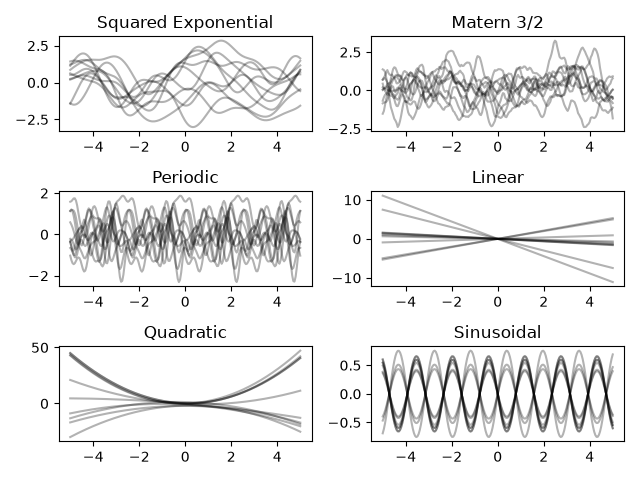

In [320]:
# Sample from some kernels

x = jnp.linspace(-5.0, 5.0, 200)

k_se = SE(1.0, 0.5)
k_mat = Mat32(1.0, 0.5)
k_per = Periodic(1.0, 0.5, 2.5)
k_lin = Linear(1.0)
k_quad = Linear(1.0, lambda xx: xx ** jnp.arange(3))
k_sin = Linear(1.0, lambda xx: jnp.sin(4 * xx))
kerns = [
    ("Squared Exponential", k_se),
    ("Matern 3/2", k_mat),
    ("Periodic", k_per),
    ("Linear", k_lin),
    ("Quadratic", k_quad),
    ("Sinusoidal", k_sin),
]


def sample_kernel(key: jr.PRNGKey, kernel: Kernel, x: jnp.ndarray, nsamp: int = 10):
    gp_prior = MultivariateGaussian(jnp.zeros((x.shape[0])), covariance(kernel)(x, x))
    return gp_prior.sample(key, nsamp=nsamp)


# Plot samples from different covariance functions (zero mean)
fig = plt.figure()
ax = fig.subplots(3, 2)
for i, (nme, kk) in enumerate(kerns):
    plt_idx = (i // 2, i % 2)
    key, ys = sample_kernel(key, kk, x)
    ax[*plt_idx].plot(x, ys.T, "k", alpha=0.3)
    ax[*plt_idx].set_title(nme)

plt.tight_layout()


### Kernel Composition

We can also compose kernels either by addition or by element-wise multiplication. There is some nice discussion in the [Kernel Cookbook](https://www.cs.toronto.edu/~duvenaud/cookbook/) which does a similar thing to this section of the notebook. I would say that some of the discussion there is a little dated now (particularly on the software recommendations) but the core concepts remain solid.

We will use similar examples to those in the cookbook for our kernel compositions.

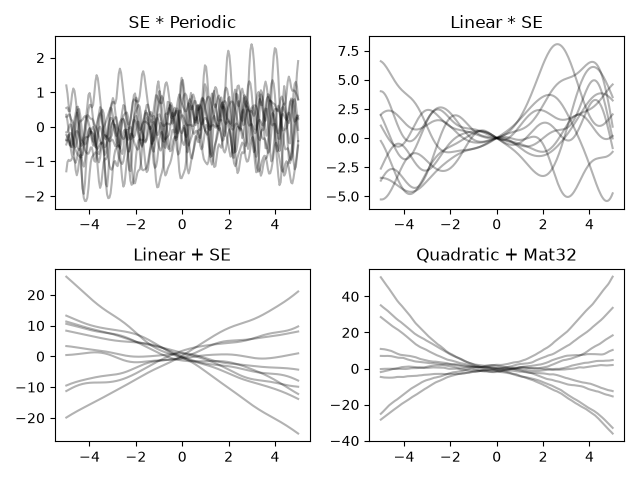

In [321]:
k_per_se = ProductKernel(SE(1.0, 10.0), Periodic(0.5, 1.0, 1.0))
k_lin_se_times = ProductKernel(SE(1.0, 1.0), Linear(1.0))
k_lin_se_add = SumKernel(SE(1.0, 1.0), Linear(4.0))
k_per_mat = SumKernel(k_quad, Mat32(0.5, 0.75))

comb_kerns = [
    ("SE * Periodic", k_per_se),
    ("Linear * SE", k_lin_se_times),
    ("Linear + SE", k_lin_se_add),
    ("Quadratic + Mat32", k_per_mat),
]

# Plot samples from different covariance functions (zero mean)
fig = plt.figure()
ax = fig.subplots(2, 2)
for i, (nme, kk) in enumerate(comb_kerns):
    plt_idx = (i // 2, i % 2)
    key, ys = sample_kernel(key, kk, x)
    ax[*plt_idx].plot(x, ys.T, "k", alpha=0.3)
    ax[*plt_idx].set_title(nme)

plt.tight_layout()

## Mean Functions

In [322]:
class ZeroMean(eqx.Module):
    """Zero Mean Function.

    Returns a static mean of zero for all input locations.
    """

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        """Evaluates the mean function.

        Args:
            x (jnp.ndarray): Input data array of shape (N, D).

        Returns:
            jnp.ndarray: A vector of zeros of shape (N,).
        """
        return jnp.zeros((x.shape[0],))


class LinearMean(eqx.Module):
    """Linear Basis Mean Function.

    Covariance for all models we can write as:
        k(x,x') = \\sigma_f^2 <\\phi(x), \\phi(x')>

    Including linear, polynomial etc.

    Hyperparameters:
        - w (jnp.ndarray): Weight vector of shape (F,).
        - basis (Callable): Feature mapping function phi(x) that maps
                            an (N, D) input to an (N, F) feature matrix.
    """

    w: jnp.ndarray
    basis: Callable[[jnp.ndarray], jnp.ndarray] = lambda xx: xx

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        """Evaluates the mean function.

        Args:
            x (jnp.ndarray): Input data array of shape (N, D).

        Returns:
            jnp.ndarray: Linear mean predictions of shape (N,).
        """
        return jnp.dot(jnp.atleast_1d(self.basis(x)), self.w)


MeanFunction = ZeroMean | LinearMean

## Exact GP Inference

In [323]:
# GP Functions


class ExactGPState(eqx.Module):
    """State of GP

    We can precompute and store the cholesky factor of \\tilde{K} and the
    "woodbury" coefficients \\tilde{K} \\alpha = y computed by backsubstitution

    """

    L: jnp.ndarray  # Lower Cholesky of \tilde{K} = K_{ff} + \sigma_n^2 I
    alpha: jnp.ndarray


class ExactGP(eqx.Module):
    """Exact Gaussian Process Regression Model.

    Work with GP models for

    y = f(x), f(x) ~ GP( m(x), k(x, x') )

    """

    mean: MeanFunction
    kernel: Kernel

    def update_state(self, x: jnp.ndarray, y: jnp.ndarray) -> ExactGPState:
        """Compute GP state from training data.

        Args:
            x (jnp.ndarray): Training inputs of shape (N, D).
            y (jnp.ndarray): Training targets of shape (N, ).

        Returns:
            ExactGPState: State containing important variables.
        """
        N = x.shape[0]
        # Compute the training covariance matrix with a nugget for numerical stability
        ktilde = covariance(self.kernel)(x, x) + NUGGET * jnp.identity(N)
        L = jnp.linalg.cholesky(ktilde)

        # Compute alpha = K^-1 * y via back-substitution: L^T * L * alpha = y - m(x)
        y -= self.mean(x)
        alpha = solve_triangular(
            L, solve_triangular(L, y, lower=True), lower=True, trans=True
        )

        return ExactGPState(L, alpha)

    def predict(
        self, x: jnp.ndarray, xs: jnp.ndarray, state: ExactGPState
    ) -> MultivariateGaussian:
        """Compute full posterior predictive

        Args:
            x (jnp.ndarray): Training inputs of shape (N, D).
            xs (jnp.ndarray): Test inputs of shape (Ns, D).
            state (ExactGPState): GP state from `update_state`.

        Returns:
            MultivariateGaussian: posterior predictive
        """
        cov = covariance(self.kernel)
        ksx = cov(xs, x)
        kss = cov(xs, xs)

        # m = m(xs) + K_sx * K_xx^-1 * y = m(xs) + K_sx * alpha
        m = self.mean(xs) + ksx @ state.alpha

        # v = K_ss - K_sx * K_xx^-1 * K_xs
        R = solve_triangular(state.L, ksx.T, lower=True)
        v = kss - R.T @ R

        return MultivariateGaussian(m, v)

    def predict_marginal(
        self, x: jnp.ndarray, xs: jnp.ndarray, state: ExactGPState
    ) -> DiagonalGaussian:
        """Compute marginal predictive

        Often we don't need the cross covariance of the predictive so
        it is more efficient to only compute the diagonal

        Args:
            x (jnp.ndarray): Training inputs of shape (N, D)
            xs (jnp.ndarray): Test inputs of shape (Ns, D)
            state (ExactGPState): GP state from `update_state`

        Returns:
            DiagonalGaussian: marginal posterior distributions
        """
        ksx = covariance(self.kernel)(xs, x)
        kss = diagonal_covariance(self.kernel)(xs)  # Only pull diagonal elements

        m = self.mean(xs) + ksx @ state.alpha

        R = solve_triangular(state.L, ksx.T, lower=True)
        v = kss - (R**2).sum(0)

        return DiagonalGaussian(m, v)

    def nlml(self, x: jnp.ndarray, y: jnp.ndarray, state: ExactGPState) -> jnp.ndarray:
        """Negative Log Marginal Likelihood

        Args:
            x (jnp.ndarray): Training inputs (N, D).
            y (jnp.ndarray): Training targets (N, ).
            state (ExactGPState): GP state from `update_state`.

        Returns:
            jnp.ndarray: negative log marginal likelihood (scalar)
        """
        N = x.shape[0]
        R = solve_triangular(state.L, y - self.mean(x), lower=True)

        # N/2 log(2π) + 0.5 log |Ktilde| + 0.5 *(y' Ktilde^-1 y)
        return (
            N / 2 * jnp.log(2 * jnp.pi)
            + jnp.log(state.L.diagonal()).sum()
            + (R**2).sum() / 2
        )

In [324]:
def plot_gp(
    x: jnp.ndarray,
    y: jnp.ndarray,
    posterior: Union["MultivariateGaussian", "DiagonalGaussian", "IsotropicGaussian"],
    ax: Optional[plt.Axes] = None,
    nsig: Union[float, int] = 3,
) -> None:
    """
    Plots the true data, the GP mean prediction, and a shaded uncertainty region.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    classname = type(posterior).__name__

    if "Multivariate" in classname:
        std = jnp.sqrt(posterior.sigma.diagonal())
    elif "Diagonal" in classname:
        std = jnp.sqrt(posterior.sigma)
    elif "Isotropic" in classname:
        std = jnp.sqrt(posterior.sigma) * jnp.ones_like(posterior.mu)
    else:
        raise TypeError(f"Unsupported posterior distribution type: {classname}")

    x_plot = jnp.atleast_1d(x).squeeze()
    mean_plot = jnp.atleast_1d(posterior.mu).squeeze()
    std_plot = jnp.atleast_1d(std).squeeze()

    lower_bound = mean_plot - nsig * std_plot
    upper_bound = mean_plot + nsig * std_plot

    ax.plot(x, y, color="black", linestyle="--", label="Observed Data")
    ax.plot(x_plot, mean_plot, color="tab:blue", lw=2, label="GP Mean")

    ax.fill_between(
        x_plot,
        lower_bound,
        upper_bound,
        color="tab:blue",
        alpha=0.2,
        label=f"±{nsig} Std. Dev.",
    )

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend(loc="best")
    ax.grid(True, linestyle="--", alpha=0.5)

ExactGP(
  mean=LinearMean(w=Array(1.48145665, dtype=float64)),
  kernel=SE(
    sf2=Array(2.67446617, dtype=float64), ll=Array(0.91494248, dtype=float64)
  )
)


Text(0, 0.5, 'NLML')

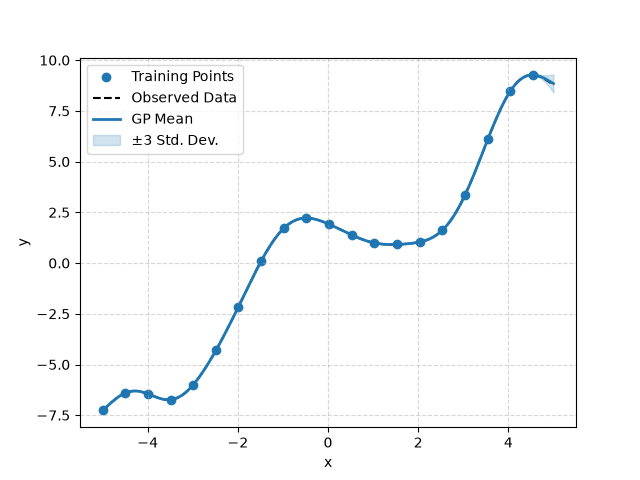

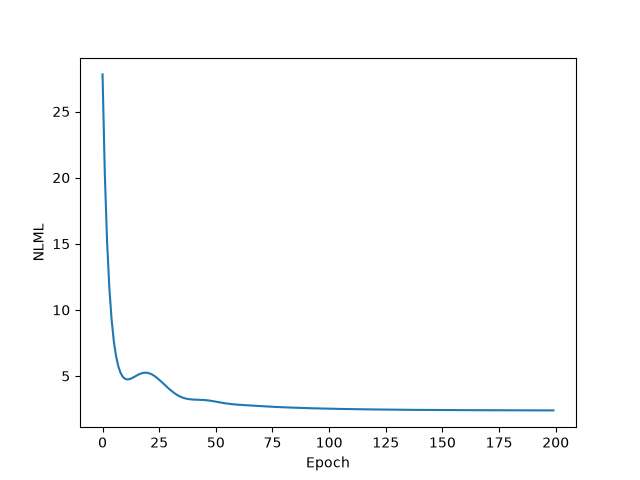

In [325]:
# GP Hyperparameter Optimisation


def fit(
    data: Tuple[jnp.ndarray, jnp.ndarray], gp: ExactGP, opt, max_iters: int = 200
) -> Tuple[ExactGP, jnp.ndarray]:
    """Fits an Exact Gaussian Process model by optimizing its hyperparameters.

    This function optimises the trainable parameters of an `ExactGP` model by
    minimizing its Negative Log Marginal Likelihood (NLML). It features specific
    handling for kernel stability and parameter constraints:

    1. Parameter Freezing: we don't train the period of periodic kernels
    2. Unconstrained Optimization: we softplus all kernel hyperparameters

    Args:
        data: tuple containing the training data (x, y), shape (N, D), (N, )
        gp: an instance of `ExactGP` to be optimised
        opt: an Optax optimizer instance (e.g., `optax.adam`).
        max_iters: number of optimization steps to perform. Defaults to 200.

    Returns:
        Tuple containing:
            - ExactGP: The optimized Gaussian Process model with updated
            hyperparameters.
            - jnp.ndarray: A record of the loss values (NLML) across all iterations.
    """

    # We never want the period of the periodic kernel to be trained... too unstable.
    trainable, static = eqx.partition(
        gp,
        jax.tree.map_with_path(
            lambda pp, ll: (
                True if pp[-1].name != "pp" and eqx.is_array_like(ll) else False
            ),
            gp,
        ),
    )

    # Apply positive transform on kernel hyperparameters.
    transform_mask = jax.tree_util.tree_map(lambda _: False, trainable)
    transform_mask = eqx.tree_at(
        lambda m: m.kernel,
        transform_mask,
        replace_fn=lambda subtree: jax.tree.map(eqx.is_array_like, subtree),
    )

    # Softplus and inverse for our positive only hyperparameters
    def _param_mapping(tree):
        return jax.tree.map(
            lambda x, mask: jnp.log(1 + jnp.exp(x)) if mask else x, tree, transform_mask
        )

    def _inv_param_mapping(tree):
        return jax.tree.map(
            lambda x, mask: jnp.log(jnp.exp(x) - 1) if mask else x, tree, transform_mask
        )

    # Move parameters to training space
    trainable = _inv_param_mapping(trainable)

    # Training objective: remap parameters, update GP, compute marginal likelihood
    def _cost(trainable: ExactGP, static: ExactGP):
        trainable = _param_mapping(trainable)
        model = eqx.combine(trainable, static)
        state = model.update_state(*data)
        cost = model.nlml(*data, state)
        return cost

    # Actual value and gradient calculation only on trainable part
    _cost_frozen = jax.value_and_grad(jax.jit(partial(lambda tt: _cost(tt, static))))

    # Optimisation step
    def _step(carry, xs):
        train, opt_state = carry
        v, g = _cost_frozen(train)
        updates, opt_state = opt.update(g, opt_state)
        train = optax.apply_updates(train, updates)
        return (train, opt_state), v

    # Perform the optimisation for max_iters epochs
    opt_state = opt.init(trainable)
    (trainable, opt_state), cost_log = jax.lax.scan(
        _step, (trainable, opt_state), None, length=max_iters
    )

    # Rebuild the model before returning
    return (eqx.combine(_param_mapping(trainable), static), cost_log)


# Set up a GP
m = LinearMean(jnp.array(1.2))
k = SE(3.0, 0.9)
# k = Periodic(3.0, 1.0, 3.0)
gp = ExactGP(m, k)

# Sample from the GP then learn it
x = jnp.linspace(-5.0, 5.0, 200)
key, y = sample_kernel(key, k, x, 1)
y = m(x) + y.squeeze()

# Take every 10th point
xtr = x[::10]
ytr = y[::10]


# Plot our training data
fig = plt.figure()
ax = fig.add_subplot()
ax.scatter(xtr, ytr, label="Training Points")

# User Adam as our optimiser, doesn't matter too much
opt = optax.adam(5e-2)

# Make some initial hyperparameters all 1.0 - usually just set as you build the GP
# here it is silly to start where we know the "true" hyperparameters
gp0 = jax.tree.map_with_path(
    lambda pp, xx: 1.0 if eqx.is_array_like(xx) and pp[-1].name != "pp" else xx, gp
)

# Fit the GP
gp_opt, cost_log = fit((xtr, ytr), gp0, opt)

# Predict over the whole dataset
gp_state = gp_opt.update_state(xtr, ytr)
posterior_predictive = gp_opt.predict_marginal(xtr, x, gp_state)

# Plot our predictions
plot_gp(x, y, posterior_predictive, ax, 3)

# Print out the optimised GP model
eqx.tree_pprint(gp_opt, short_arrays=False)

# Also plot the progression of our loss function
plt.figure()
plt.plot(cost_log)
plt.xlabel("Epoch")
plt.ylabel("NLML")

## CHF Data



In [326]:
DATA_PATH = "../../../data"

# Check we can access data appropriately
try:
    print(f"Available Data: {', '.join([f for f in os.listdir(DATA_PATH)])}")
except FileNotFoundError:
    print(
        f"""
        Data files not available at path: {DATA_PATH}. \n
        Check your working directory, currently you are in {os.getcwd()}\n
        You are expected to be in ...nth-summer-school/ai4nth-summer-school/course_materials/day3_surrogates_gp/solutions for relative path to work.
        """
    )

df = pd.read_csv(DATA_PATH + "/chf_GP.csv", sep=",", header=0)

# Print out the top rows of our "GP" dataset to see what we've got.
display(df.head())


Available Data: chf_OOD_Kim2000.csv, chf_OOD_Lee1966.csv, chf_val.csv, chf_GP.csv, chf_OOD_Peterlongo1966.csv, chf_ong.csv, chf_test.csv, chf_train.csv


,Number,Reference ID,Tube Diameter (m),Heated Length (m),Pressure (kPa),Mass Flux (kg/m^2/s),Outlet Quality,Inlet Subcooling (kJ/kg),Inlet Temperature (degreeC ),CHF (kW/m^2),Reference name
0,3387,13,0.01,1.0,9800.0,570.0,0.421,923.0,111.88,2095.0,Alekseev 1954
1,3388,13,0.01,1.0,9800.0,676.0,0.378,898.0,117.82,2351.0,Alekseev 1954
2,3389,13,0.01,1.0,9800.0,849.0,0.291,884.0,121.14,2678.0,Alekseev 1954
3,3390,13,0.01,1.0,9800.0,941.0,0.247,866.0,125.40,2787.0,Alekseev 1954
4,3391,13,0.01,1.0,9800.0,970.0,0.238,921.0,112.36,2976.0,Alekseev 1954


Start by looking at a restricted dataset just to see what's what and maybe fit a GP.

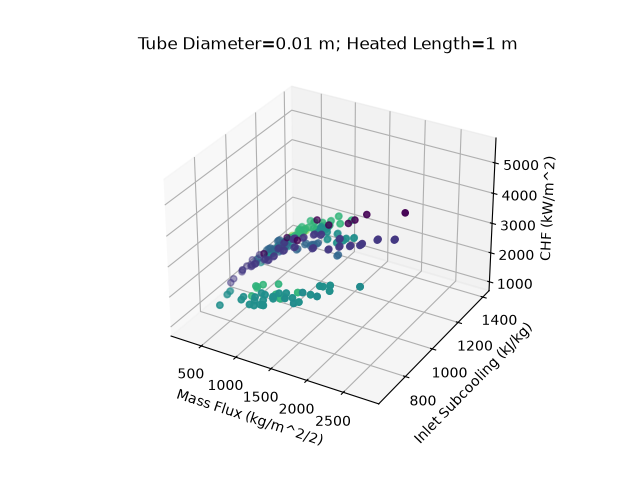

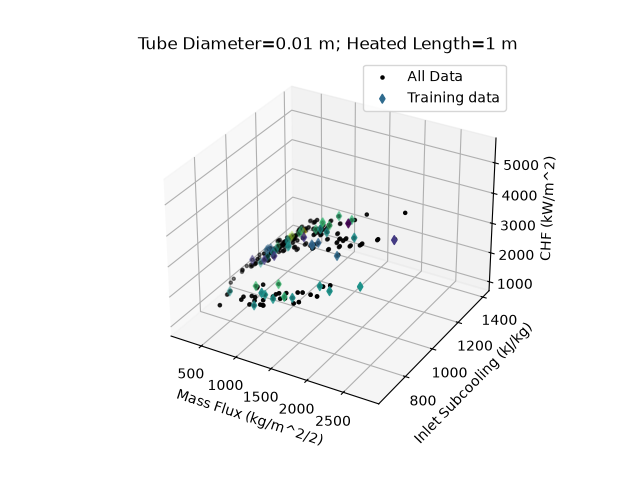

In [356]:
# Only look in these conditions
tube_diam = ("Tube Diameter (m)", 0.01)
heated_length = ("Heated Length (m)", 1.0)
pressure = ("Pressure (kPa)", 0)  # Use all pressures


# Then let's try look at the relationship MF, IS, Pressure -> CHF
fd = df[
    (df[heated_length[0]] == heated_length[1])
    & (df[pressure[0]] >= pressure[1])
    & (df[tube_diam[0]] == tube_diam[1])
]

fig = plt.figure()
ax = fig.add_subplot(projection="3d")
ax.scatter(
    fd["Mass Flux (kg/m^2/s)"],
    fd["Inlet Subcooling (kJ/kg)"],
    fd["CHF (kW/m^2)"],
    c=fd["Pressure (kPa)"],
)
ax.set_xlabel("Mass Flux (kg/m^2/2)")
ax.set_ylabel("Inlet Subcooling (kJ/kg)")
ax.set_zlabel("CHF (kW/m^2)")
ax.set_title("Tube Diameter=0.01 m; Heated Length=1 m")


N_total = fd.shape[0]
N = 200
tr_idx = np.random.choice(fd.shape[0], (50,))

x = fd[
    ["Mass Flux (kg/m^2/s)", "Inlet Subcooling (kJ/kg)", "Pressure (kPa)"]
].to_numpy()
y = fd["CHF (kW/m^2)"].to_numpy()
xtr = x[tr_idx]
ytr = y[tr_idx]


fig = plt.figure()
ax = fig.add_subplot(projection="3d")
ax.scatter(x[:, 0], x[:, 1], y, c="k", marker=".", label="All Data")
ax.scatter(
    x[tr_idx, 0],
    x[tr_idx, 1],
    y[tr_idx],
    c=x[tr_idx, 2],
    marker="d",
    label="Training data",
)
ax.set_xlabel("Mass Flux (kg/m^2/2)")
ax.set_ylabel("Inlet Subcooling (kJ/kg)")
ax.set_zlabel("CHF (kW/m^2)")
ax.set_title("Tube Diameter=0.01 m; Heated Length=1 m")
plt.legend()


ExactGP(
  mean=LinearMean(
    w=Array([ 1.03578806,  0.36768202, -0.28634879], dtype=float64)
  ),
  kernel=SE(
    sf2=Array(0.07023265, dtype=float64), ll=Array(0.30846106, dtype=float64)
  )
)


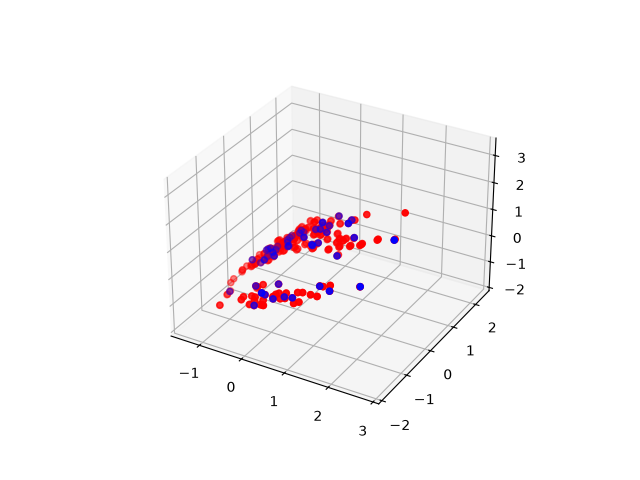

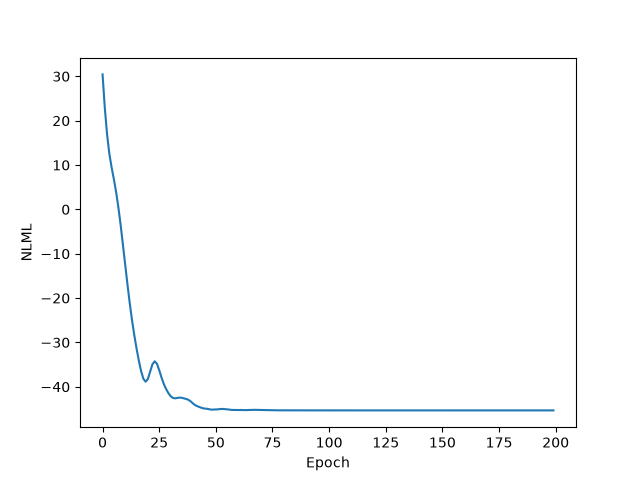

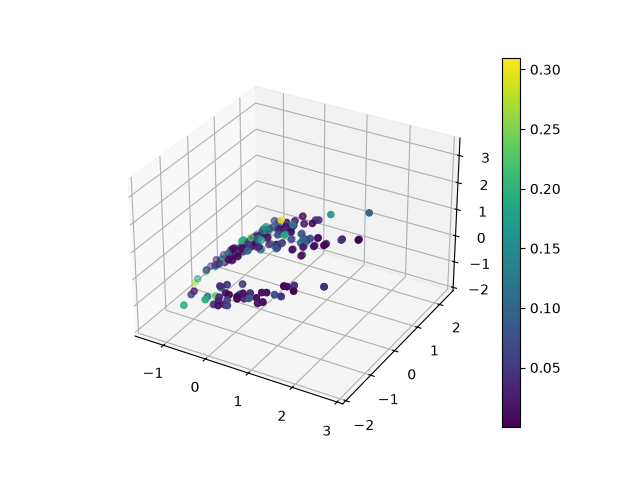

In [360]:
class Normaliser(eqx.Module):
    @staticmethod
    def self_normalise(
        x: jnp.ndarray,
    ) -> Tuple[jnp.ndarray, Tuple[jnp.ndarray, jnp.ndarray]]:
        m = x.mean(0, keepdims=True)
        s = x.std(0, keepdims=True)

        return (x - m) / s, (m, s)

    @staticmethod
    def normalise(
        x: jnp.ndarray, scales: Tuple[jnp.ndarray, jnp.ndarray]
    ) -> jnp.ndarray:
        m, s = scales
        return (x - m) / s

    @staticmethod
    def denormalise(
        x: jnp.ndarray, scales: Tuple[jnp.ndarray, jnp.ndarray]
    ) -> jnp.ndarray:
        m, s = scales
        return x * s + m


# Put everything in 0 mean, unit standard deviation
xtr_norm, x_norms = Normaliser.self_normalise(xtr)
ytr_norm, y_norms = Normaliser.self_normalise(ytr)

x_test = Normaliser.normalise(x, x_norms)
y_test = Normaliser.normalise(y, y_norms)


fig = plt.figure()
ax = fig.add_subplot(projection="3d")
ax.scatter(x_test[:, 0], x_test[:, 1], y_test, c="r")
ax.scatter(xtr_norm[:, 0], xtr_norm[:, 1], ytr_norm, c="b")


m = LinearMean(jnp.zeros((xtr_norm.shape[1],)))
k = SE(1.0, 0.1)  # We have scaled to unit standard deviation...

gp = ExactGP(m, k)
opt = optax.adam(1e-1)

gp, cost_log = fit((xtr_norm, ytr_norm), gp, opt)

plt.figure()
plt.plot(cost_log)
plt.xlabel("Epoch")
plt.ylabel("NLML")

gp_state = gp.update_state(xtr_norm, ytr_norm)
posterior_predictive = gp.predict_marginal(xtr_norm, x_test, gp_state)

residual = jnp.sqrt((y_test - posterior_predictive.mu) ** 2)

fig = plt.figure()
ax = fig.add_subplot(projection="3d")
p = ax.scatter(x_test[:, 0], x_test[:, 1], y_test, c=residual)
fig.colorbar(p)
# ax.scatter(x_test[:, 0], x_test[:, 1], posterior_predictive.mu, "b")
# ax.scatter(x_test[:, 0], x_test[:, 1], y_test - posterior_predictive.mu, "k")

eqx.tree_pprint(gp, short_arrays=False)
